# TRAPPIST-1e: vertical profiles and posterior retrievals

This notebook combines two ideas into a single figure:

- true vertical profiles for `A0` and `A3` for each molecule;
- marginal abundance posteriors for the observation combinations used in the retrieval campaign.

The columns remain fixed by molecule. The rows are now observational retrieval configurations, such as MIRI-only, NIRSpec-only, and NIRSpec+MIRI at a fixed observing budget.

The annotations use two robust metrics when both `A0` and `A3` are available for the same row:

- `sigma68 = (q84 - q16) / 2` as the characteristic posterior width;
- `sep_sigma = |med_A3 - med_A0| / sqrt(sigma68_A0^2 + sigma68_A3^2)` as the separation between scenarios.

Note: `A0` and `A3` come from retrievals on different synthetic datasets. The notebook reports each retrieval's `ln Z`, but does not interpret a direct Bayes factor between them.

In [1]:
from __future__ import annotations

from pathlib import Path
import re

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, VPacker

try:
    import pandas as pd
except ImportError:
    pd = None

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = [
    "STIXGeneral",
    "DejaVu Serif",
    "Times New Roman",
    "CMU Serif",
    "Liberation Serif",
]
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.titleweight"] = "normal"
mpl.rcParams["axes.titlepad"] = 10
mpl.rcParams["figure.titlesize"] = 16
mpl.rcParams["figure.titleweight"] = "normal"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.size": 10,
})

SEED = 7
np.random.seed(SEED)
SEED


7

## Configuration

Adjust `MOLECULES` if you want fewer columns. Adjust `OBSERVATION_RETRIEVALS` if the retrieval campaign gains or removes observation combinations.

In [2]:
SCENARIOS = {
    "A0": {
        "label": "A0 (PreAgri)",
        "profile_stem": "Trappist_A0_PreAgri",
        "color": "#e76f51",
    },
    "A3": {
        "label": "A3 (Extreme)",
        "profile_stem": "Trappist_A3_Extreme",
        "color": "#2a9d8f",
    },
}

SCENARIO_ORDER = ("A0", "A3")
OBSERVATION_RETRIEVALS = (
    {"key": "5_MIRI", "label": "5 MIRI", "n_transits": 5, "instrument_suffix": "MIRI"},
    {"key": "5_NIRSpec", "label": "5 NIRSpec", "n_transits": 5, "instrument_suffix": "NIRSpec"},
    {"key": "5_NIRSpec_MIRI", "label": "5 NIRSpec + MIRI", "n_transits": 5, "instrument_suffix": "NIRSpec_MIRI"},
    {"key": "10_MIRI", "label": "10 MIRI", "n_transits": 10, "instrument_suffix": "MIRI"},
    {"key": "10_NIRSpec", "label": "10 NIRSpec", "n_transits": 10, "instrument_suffix": "NIRSpec"},
    {"key": "10_NIRSpec_MIRI", "label": "10 NIRSpec + MIRI", "n_transits": 10, "instrument_suffix": "NIRSpec_MIRI"},
    {"key": "20_MIRI", "label": "20 MIRI", "n_transits": 20, "instrument_suffix": "MIRI"},
    {"key": "20_NIRSpec", "label": "20 NIRSpec", "n_transits": 20, "instrument_suffix": "NIRSpec"},
    {"key": "20_NIRSpec_MIRI", "label": "20 NIRSpec + MIRI", "n_transits": 20, "instrument_suffix": "NIRSpec_MIRI"},
    {"key": "100_MIRI", "label": "100 MIRI", "n_transits": 100, "instrument_suffix": "MIRI"},
    {"key": "100_NIRSpec", "label": "100 NIRSpec", "n_transits": 100, "instrument_suffix": "NIRSpec"},
    {"key": "100_NIRSpec_MIRI", "label": "100 NIRSpec + MIRI", "n_transits": 100, "instrument_suffix": "NIRSpec_MIRI"},
)
MOLECULES = ("H2O", "CO2", "CH4", "O2", "O3", "N2O", "NH3")
ABUNDANCE_FLOOR = 1.0e-80

PLOT_LABELS = {
    "H2O": r"H$_2$O",
    "CO2": r"CO$_2$",
    "CH4": r"CH$_4$",
    "O2": r"O$_2$",
    "O3": r"O$_3$",
    "N2O": r"N$_2$O",
    "NH3": r"NH$_3$",
}

X_AXIS_LABELS = {
    "H2O": r"log(X$_{\mathrm{H_2O}}$)",
    "CO2": r"log(X$_{\mathrm{CO_2}}$)",
    "CH4": r"log(X$_{\mathrm{CH_4}}$)",
    "O2": r"log(X$_{\mathrm{O_2}}$)",
    "O3": r"log(X$_{\mathrm{O_3}}$)",
    "N2O": r"log(X$_{\mathrm{N_2O}}$)",
    "NH3": r"log(X$_{\mathrm{NH_3}}$)",
}

def find_repo_root(start: Path | None = None) -> Path:
    """Return the repository root by walking upward from the current path."""
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "Transmission_Spectroscopy").exists() and (candidate / "README.md").exists():
            return candidate
    raise FileNotFoundError("No pude ubicar la raiz del repo desde el directorio actual.")

def load_named_table(path: Path, delimiter: str | None = None):
    """Load a text table into named column arrays."""
    with path.open("r", encoding="utf-8") as fh:
        first_line = fh.readline().strip()
        if delimiter is None:
            header = first_line.split()
        else:
            header = [chunk.strip() for chunk in first_line.split(delimiter)]
    data = np.loadtxt(path, skiprows=1)
    data = np.atleast_2d(data)
    return {name: data[:, idx] for idx, name in enumerate(header)}

def retrieval_stem(scenario_key: str, observation: dict) -> str:
    """Build the POSEIDON retrieval product stem for one observation configuration."""
    suffix = observation.get("instrument_suffix", "")
    suffix_part = f"_{suffix}" if suffix else ""
    return (
        f"TRAPPIST1e_{scenario_key}_retrieval_isotherm_isochem_"
        f"{observation['n_transits']}transits{suffix_part}"
    )

def retrieval_path(repo_root: Path, scenario_key: str, observation: dict, kind: str) -> Path:
    """Build the path to a POSEIDON retrieval export file."""
    suffix = "samples" if kind == "samples" else "results"
    return (
        repo_root
        / "Transmission_Spectroscopy"
        / "notebooks"
        / "POSEIDON_output"
        / "TRAPPIST-1e"
        / "retrievals"
        / suffix
        / f"{retrieval_stem(scenario_key, observation)}_{suffix}.txt"
    )

def profile_path(repo_root: Path, scenario_key: str) -> Path:
    """Build the path to the reference chemical profile for one scenario."""
    stem = SCENARIOS[scenario_key]["profile_stem"]
    return repo_root / "Transmission_Spectroscopy" / "profiles" / f"{stem}_chem.txt"

def load_log_evidence(repo_root: Path, scenario_key: str, observation: dict) -> dict[str, float]:
    """Extract ln Z and its quoted uncertainty from a POSEIDON results file."""
    path = retrieval_path(repo_root, scenario_key, observation, "results")
    if not path.exists():
        raise FileNotFoundError(path)
    text = path.read_text(encoding="utf-8")
    match = re.search(r"ln Z =\s*([+-]?\d+(?:\.\d+)?)\s*\+/-\s*([+-]?\d+(?:\.\d+)?)", text)
    if match is None:
        raise ValueError(f"No pude leer ln Z desde {path}")
    return {
        "ln_Z": float(match.group(1)),
        "ln_Z_err": float(match.group(2)),
    }

def log_profile(profile: dict[str, np.ndarray], molecule: str) -> np.ndarray:
    """Return log10 abundance, clipped to a floor to avoid -inf values."""
    return np.log10(np.clip(profile[molecule], ABUNDANCE_FLOOR, None))

def posterior_summary(values: np.ndarray) -> dict[str, float]:
    """Summarize one marginal posterior with central quantiles and width metrics."""
    q16, q50, q84 = np.percentile(values, [16.0, 50.0, 84.0])
    return {
        "q16": float(q16),
        "median": float(q50),
        "q84": float(q84),
        "sigma68": float(0.5 * (q84 - q16)),
        "mean": float(np.mean(values)),
        "std": float(np.std(values, ddof=1)),
    }

def z_separation(summary_a: dict[str, float], summary_b: dict[str, float]) -> float:
    """Measure separation between posterior medians in units of combined sigma68."""
    denom = np.hypot(summary_a["sigma68"], summary_b["sigma68"])
    if denom == 0.0:
        return float("nan")
    return abs(summary_a["median"] - summary_b["median"]) / denom

def scenario_sigma(summary_ref: dict[str, float], summary_other: dict[str, float]) -> float:
    """Measure how far the other scenario median lies from the reference posterior."""
    sigma = summary_ref["sigma68"]
    if sigma == 0.0:
        return float("nan")
    return abs(summary_other["median"] - summary_ref["median"]) / sigma

def profile_pressure_limits(profile_store) -> tuple[float, float]:
    """Compute the shared positive pressure range across all vertical profiles."""
    pressures = np.concatenate([
        np.asarray(profile_store[scenario_key]["PRESS"])
        for scenario_key in SCENARIO_ORDER
    ])
    positive = pressures[np.isfinite(pressures) & (pressures > 0.0)]
    return float(np.nanmin(positive)), float(np.nanmax(positive))

def combined_xlim(molecule: str, sample_store, profile_store) -> tuple[float, float]:
    """Set a shared x-range from profiles and all loaded posteriors."""
    arrays = []
    for scenario_key in SCENARIO_ORDER:
        arrays.append(log_profile(profile_store[scenario_key], molecule))
        for observation in OBSERVATION_RETRIEVALS:
            values = sample_store.get((scenario_key, observation["key"]))
            if values is not None:
                arrays.append(values[f"log_{molecule}"])
    finite_values = np.concatenate([arr[np.isfinite(arr)] for arr in arrays])
    # Percentile clipping keeps a few extreme draws from dominating the axis range.
    x_min = float(np.percentile(finite_values, 0.5))
    x_max = float(np.percentile(finite_values, 99.5))
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        x_min, x_max = -10.0, 0.0
    padding = 0.35 * max(1.0, x_max - x_min)
    return x_min - padding, x_max + padding

In [3]:
repo_root = find_repo_root()

sample_store = {}
evidence_store = {}
missing_retrievals = []
for observation in OBSERVATION_RETRIEVALS:
    for scenario_key in SCENARIO_ORDER:
        sample_path = retrieval_path(repo_root, scenario_key, observation, "samples")
        result_path = retrieval_path(repo_root, scenario_key, observation, "results")
        if sample_path.exists():
            sample_store[(scenario_key, observation["key"])] = load_named_table(sample_path, delimiter="|")
        else:
            missing_retrievals.append((scenario_key, observation["label"], sample_path.name))
        if result_path.exists():
            evidence_store[(scenario_key, observation["key"])] = load_log_evidence(repo_root, scenario_key, observation)

if not sample_store:
    raise FileNotFoundError("No se encontro ningun archivo de samples para OBSERVATION_RETRIEVALS.")

profile_store = {
    scenario_key: load_named_table(profile_path(repo_root, scenario_key))
    for scenario_key in SCENARIO_ORDER
}

summary_store = {}
comparison_rows = []
for observation in OBSERVATION_RETRIEVALS:
    obs_key = observation["key"]
    for molecule in MOLECULES:
        scenario_summaries = {}
        for scenario_key in SCENARIO_ORDER:
            samples = sample_store.get((scenario_key, obs_key))
            if samples is None:
                continue
            summary = posterior_summary(samples[f"log_{molecule}"])
            summary_store[(scenario_key, obs_key, molecule)] = summary
            scenario_summaries[scenario_key] = summary

        a0_summary = scenario_summaries.get("A0")
        a3_summary = scenario_summaries.get("A3")
        comparison_rows.append({
            "observation": observation["label"],
            "n_transits": observation["n_transits"],
            "instrument": observation["instrument_suffix"],
            "molecule": molecule,
            "A0_median": np.nan if a0_summary is None else a0_summary["median"],
            "A0_sigma68": np.nan if a0_summary is None else a0_summary["sigma68"],
            "A0_sigma_sep": np.nan if a0_summary is None or a3_summary is None else scenario_sigma(a0_summary, a3_summary),
            "A0_lnZ": evidence_store.get(("A0", obs_key), {}).get("ln_Z", np.nan),
            "A3_median": np.nan if a3_summary is None else a3_summary["median"],
            "A3_sigma68": np.nan if a3_summary is None else a3_summary["sigma68"],
            "A3_sigma_sep": np.nan if a0_summary is None or a3_summary is None else scenario_sigma(a3_summary, a0_summary),
            "A3_lnZ": evidence_store.get(("A3", obs_key), {}).get("ln_Z", np.nan),
            "sep_sigma": np.nan if a0_summary is None or a3_summary is None else z_separation(a0_summary, a3_summary),
        })

x_limits = {molecule: combined_xlim(molecule, sample_store, profile_store) for molecule in MOLECULES}
profile_ylim = profile_pressure_limits(profile_store)
loaded_retrievals = sorted(sample_store)

repo_root, loaded_retrievals, missing_retrievals[:5]

(WindowsPath('C:/Proyectos/Astro/ExoFarm_MDwarfs'),
 [('A0', '100_MIRI'),
  ('A0', '100_NIRSpec'),
  ('A0', '100_NIRSpec_MIRI'),
  ('A0', '10_MIRI'),
  ('A0', '10_NIRSpec'),
  ('A0', '10_NIRSpec_MIRI'),
  ('A0', '20_MIRI'),
  ('A0', '20_NIRSpec'),
  ('A0', '20_NIRSpec_MIRI'),
  ('A0', '5_MIRI'),
  ('A0', '5_NIRSpec'),
  ('A0', '5_NIRSpec_MIRI'),
  ('A3', '100_MIRI'),
  ('A3', '100_NIRSpec'),
  ('A3', '100_NIRSpec_MIRI'),
  ('A3', '10_MIRI'),
  ('A3', '10_NIRSpec'),
  ('A3', '10_NIRSpec_MIRI'),
  ('A3', '20_MIRI'),
  ('A3', '20_NIRSpec'),
  ('A3', '20_NIRSpec_MIRI'),
  ('A3', '5_MIRI'),
  ('A3', '5_NIRSpec'),
  ('A3', '5_NIRSpec_MIRI')],
 [])

In [4]:
if pd is not None:
    comparison_df = pd.DataFrame(comparison_rows)
    comparison_df = comparison_df.round({
        "A0_median": 2,
        "A0_sigma68": 2,
        "A0_sigma_sep": 2,
        "A0_lnZ": 2,
        "A3_median": 2,
        "A3_sigma68": 2,
        "A3_sigma_sep": 2,
        "A3_lnZ": 2,
        "sep_sigma": 2,
    })
    display(comparison_df)
else:
    comparison_rows


,observation,n_transits,instrument,molecule,A0_median,A0_sigma68,A0_sigma_sep,A0_lnZ,A3_median,A3_sigma68,A3_sigma_sep,A3_lnZ,sep_sigma
0,5 MIRI,5,MIRI,H2O,-4.50,2.53,0.53,629.18,-3.16,1.92,0.70,639.18,0.42
1,5 MIRI,5,MIRI,CO2,-5.37,2.88,0.03,629.18,-5.28,2.74,0.03,639.18,0.02
2,5 MIRI,5,MIRI,CH4,-5.67,2.48,0.45,629.18,-4.54,2.69,0.42,639.18,0.31
3,5 MIRI,5,MIRI,O2,-5.57,2.73,0.05,629.18,-5.44,2.75,0.05,639.18,0.03
4,5 MIRI,5,MIRI,O3,-7.06,2.14,0.42,629.18,-7.96,1.47,0.61,639.18,0.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,100 NIRSpec + MIRI,100,NIRSpec_MIRI,CH4,-4.49,0.09,0.12,2872.36,-4.48,0.08,0.14,2879.06,0.09
80,100 NIRSpec + MIRI,100,NIRSpec_MIRI,O2,-1.06,0.07,0.11,2872.36,-1.05,0.06,0.14,2879.06,0.09
81,100 NIRSpec + MIRI,100,NIRSpec_MIRI,O3,-8.67,0.89,0.92,2872.36,-9.49,0.44,1.84,2879.06,0.82
82,100 NIRSpec + MIRI,100,NIRSpec_MIRI,N2O,-6.75,0.35,2.39,2872.36,-5.92,0.26,3.27,2879.06,1.93


## Composite Figure

Each column corresponds to one molecule. Each row corresponds to one observational retrieval configuration.

- translucent histograms: loaded marginal posteriors for that observation combination;
- solid lines: true `A0` and `A3` vertical profiles on a pressure axis at the right;
- dashed lines: posterior median for each loaded scenario.

Rows with only one loaded scenario still show that posterior and its `sigma68`; A0/A3 separation metrics are shown only where both scenario retrievals exist.

(WindowsPath('C:/Proyectos/Astro/ExoFarm_MDwarfs/Transmission_Spectroscopy/notebooks/figures/trappist_profile_posterior_observation_combinations.png'),
 WindowsPath('C:/Proyectos/Astro/ExoFarm_MDwarfs/Transmission_Spectroscopy/notebooks/figures/trappist_profile_posterior_observation_combinations.pdf'))

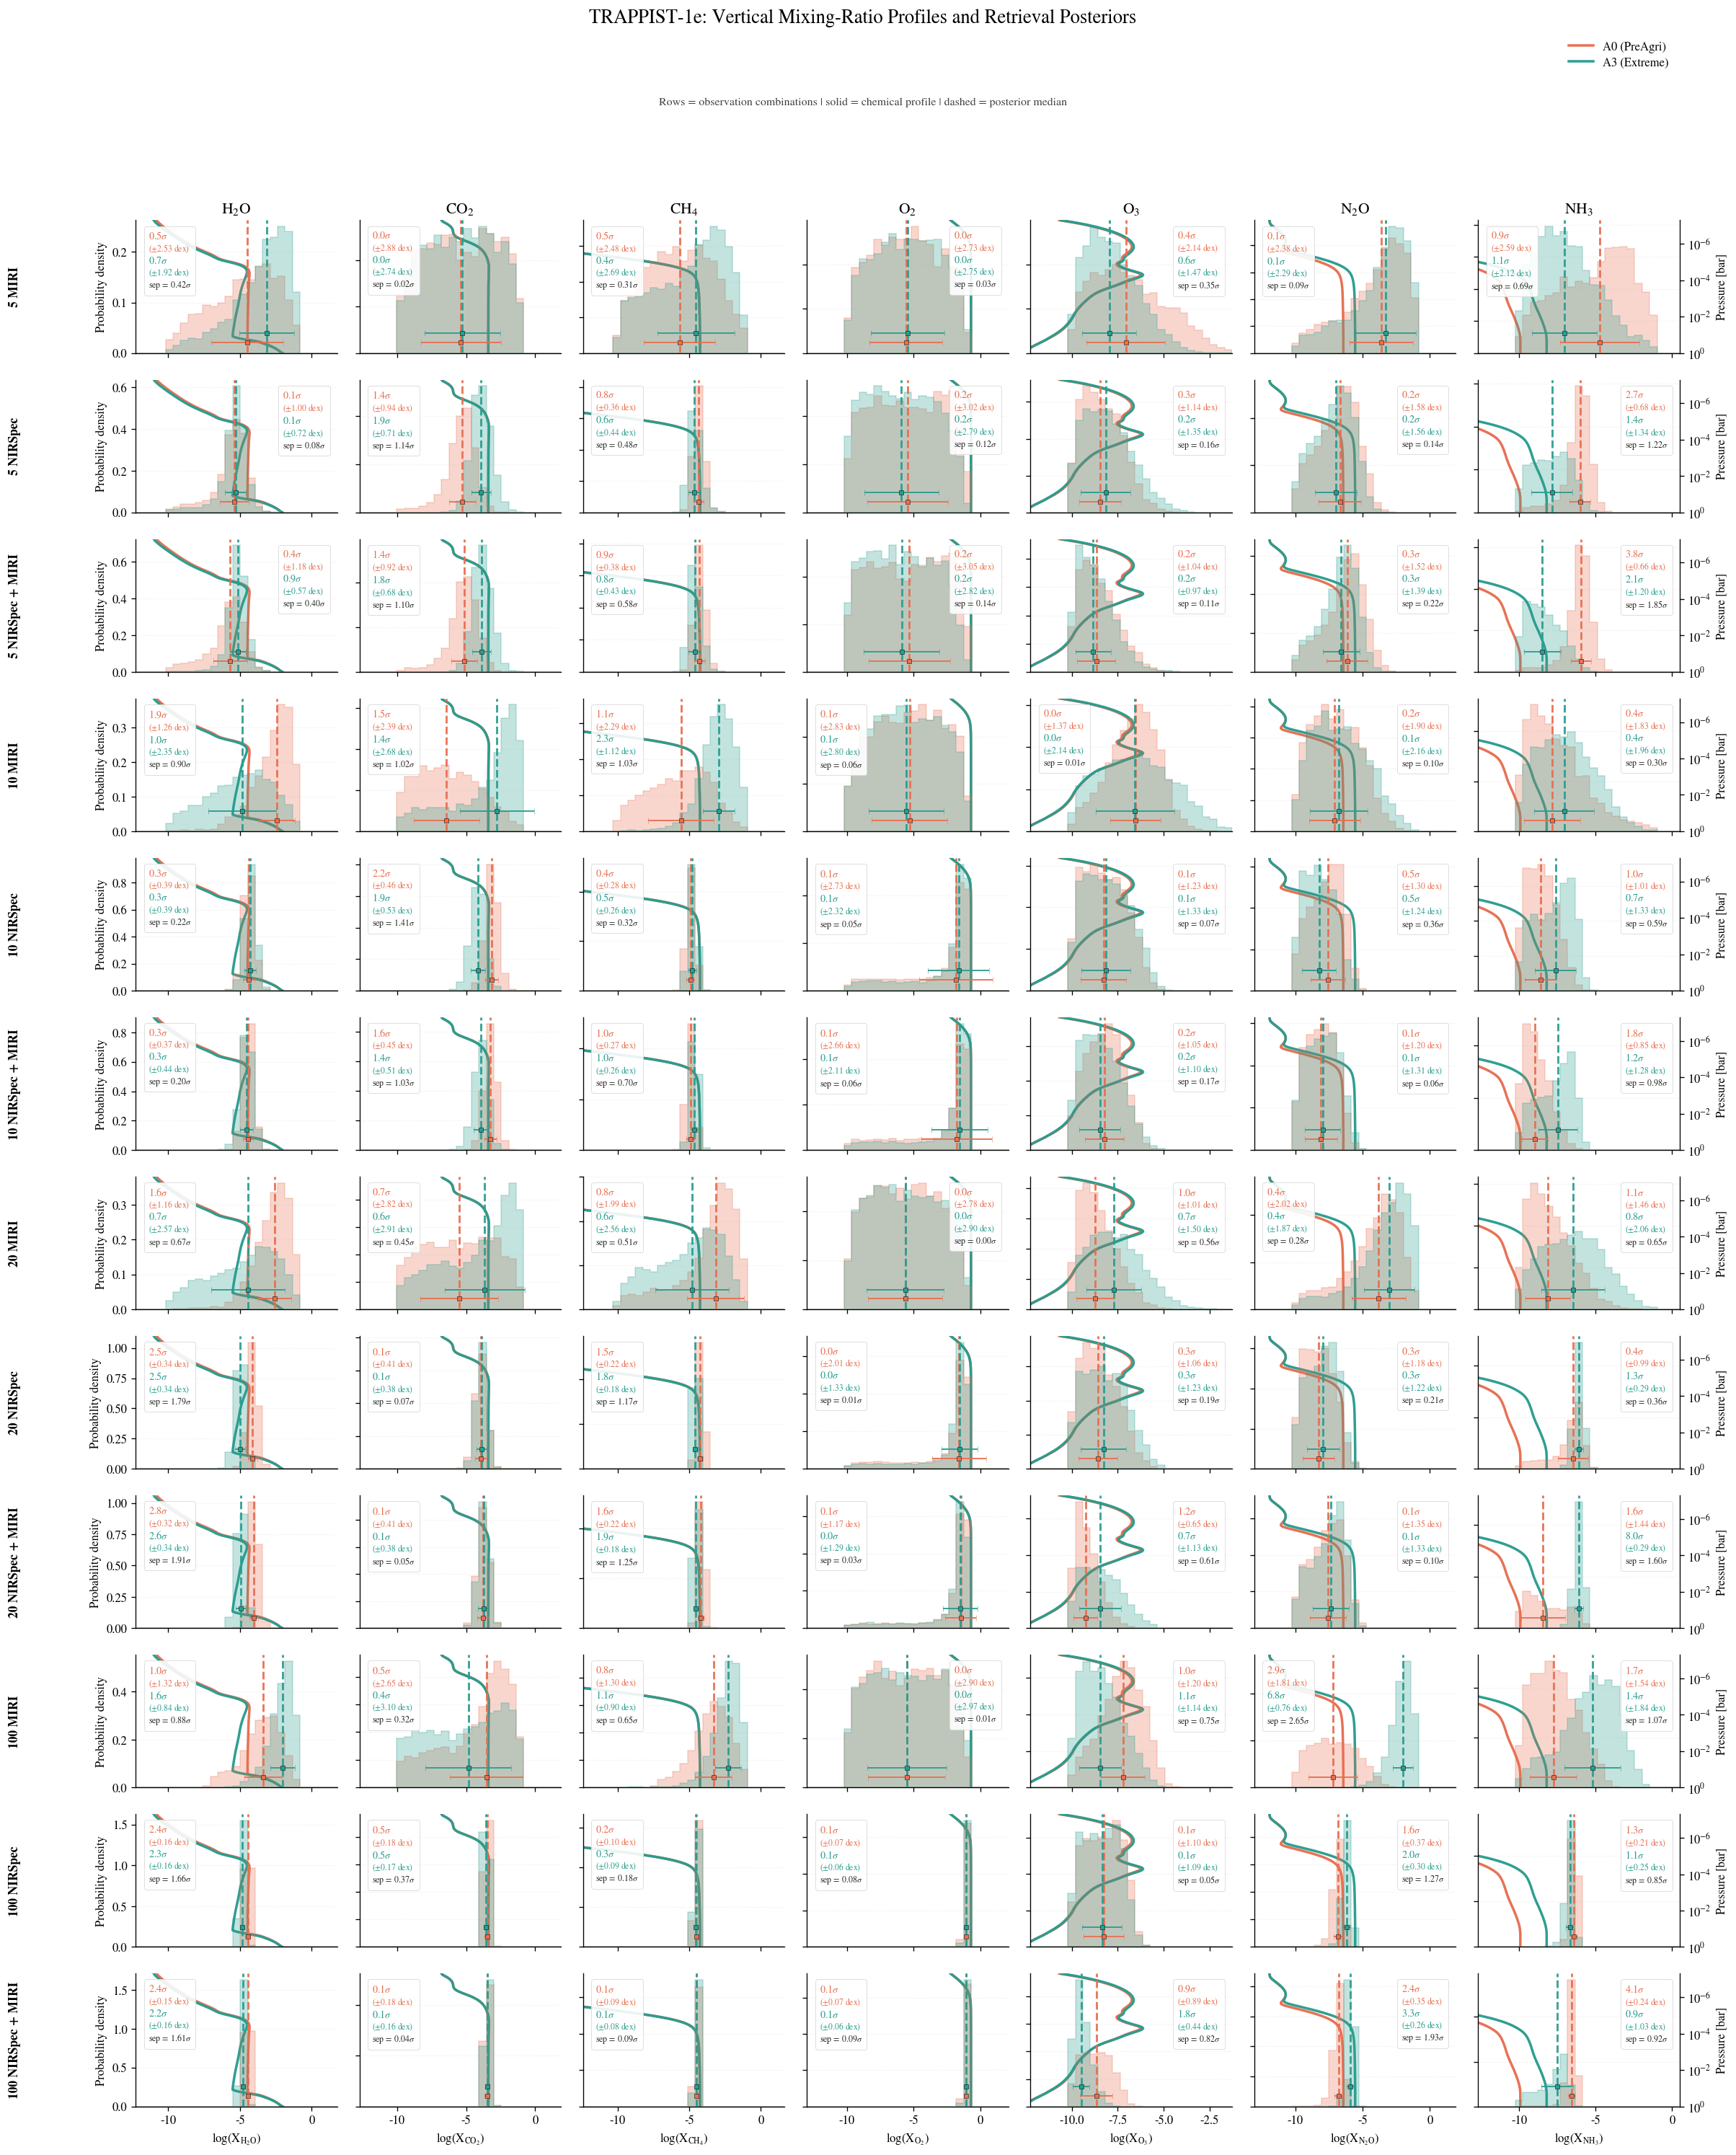

In [5]:
def plot_profile_posterior_grid(sample_store, profile_store, summary_store, x_limits, profile_ylim):
    """Overlay marginal posteriors and reference vertical profiles in a grid of panels."""
    n_rows = len(OBSERVATION_RETRIEVALS)
    n_cols = len(MOLECULES)
    fig = plt.figure(figsize=(2.78 * n_cols, 2.15 * n_rows))
    outer = fig.add_gridspec(
        n_rows,
        n_cols,
        left=0.068,
        right=0.985,
        bottom=0.055,
        top=0.90,
        wspace=0.11,
        hspace=0.20,
    )

    legend_handles = []
    for row, observation in enumerate(OBSERVATION_RETRIEVALS):
        obs_key = observation["key"]
        for col, molecule in enumerate(MOLECULES):
            ax = fig.add_subplot(outer[row, col])
            ax_prof = ax.twinx()
            # Keep the posterior artists on top while using the twin axis for pressure.
            ax.set_zorder(2)
            ax_prof.set_zorder(1)
            ax.patch.set_alpha(0.0)

            bin_edges = np.linspace(x_limits[molecule][0], x_limits[molecule][1], 28)
            loaded_scenarios = []
            for scenario_key in SCENARIO_ORDER:
                samples = sample_store.get((scenario_key, obs_key))
                if samples is None:
                    continue
                loaded_scenarios.append(scenario_key)
                style = SCENARIOS[scenario_key]
                values = samples[f"log_{molecule}"]
                summary = summary_store[(scenario_key, obs_key, molecule)]
                ax.hist(
                    values,
                    bins=bin_edges,
                    density=True,
                    histtype="stepfilled",
                    color=style["color"],
                    edgecolor=style["color"],
                    linewidth=0.9,
                    alpha=0.28,
                    zorder=1,
                )
                ax.axvline(
                    summary["median"],
                    color=style["color"],
                    lw=1.7,
                    ls="--",
                    alpha=0.95,
                    zorder=4,
                )

            for scenario_key in SCENARIO_ORDER:
                style = SCENARIOS[scenario_key]
                profile = profile_store[scenario_key]
                line = ax_prof.plot(
                    log_profile(profile, molecule),
                    profile["PRESS"],
                    color=style["color"],
                    lw=2.1,
                    alpha=0.98,
                    label=style["label"],
                    zorder=6,
                )[0]
                if row == 0 and col == 0:
                    legend_handles.append(line)

            summaries = {
                scenario_key: summary_store[(scenario_key, obs_key, molecule)]
                for scenario_key in loaded_scenarios
            }
            a0_summary = summaries.get("A0")
            a3_summary = summaries.get("A3")

            ax.set_xlim(*x_limits[molecule])
            ax.grid(axis="y", alpha=0.22, linestyle=":")
            ax.set_ylim(bottom=0.0)

            ax_prof.set_yscale("log")
            ax_prof.set_ylim(*profile_ylim)
            ax_prof.invert_yaxis()
            ax_prof.set_xlim(*x_limits[molecule])
            ax_prof.grid(False)
            ax_prof.spines["right"].set_visible(col == n_cols - 1)
            ax_prof.spines["left"].set_visible(False)
            ax_prof.spines["top"].set_visible(False)
            ax_prof.spines["bottom"].set_visible(False)

            post_ymax = ax.get_ylim()[1]
            marker_levels = np.linspace(0.08, 0.15, max(2, len(loaded_scenarios)))
            for scenario_key, marker_frac in zip(loaded_scenarios, marker_levels):
                style = SCENARIOS[scenario_key]
                summary = summaries[scenario_key]
                ax.errorbar(
                    summary["median"],
                    marker_frac * post_ymax,
                    xerr=summary["sigma68"],
                    fmt="s",
                    ms=3.5,
                    color=style["color"],
                    markerfacecolor=style["color"],
                    markeredgecolor="black",
                    markeredgewidth=0.3,
                    elinewidth=1.1,
                    capsize=2.3,
                    zorder=7,
                )

            if row == 0:
                ax.set_title(PLOT_LABELS[molecule], fontsize=13, pad=6)

            if col == 0:
                ax.text(
                    -0.60,
                    0.5,
                    observation["label"],
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=10.5,
                    fontweight="bold",
                )
                ax.set_ylabel("Probability density")
            else:
                ax.tick_params(axis="y", labelleft=False)

            if col == n_cols - 1:
                ax_prof.tick_params(axis="y", which="both", right=True, labelright=True)
                ax_prof.set_ylabel("Pressure [bar]")
            else:
                ax_prof.tick_params(axis="y", which="both", left=False, right=False, labelleft=False, labelright=False)
                ax_prof.set_yticks([])
                ax_prof.set_yticks([], minor=True)

            if row == n_rows - 1:
                ax.set_xlabel(X_AXIS_LABELS[molecule])
            else:
                ax.tick_params(axis="x", labelbottom=False)

            if a0_summary is not None and a3_summary is not None:
                a0_sigma = scenario_sigma(a0_summary, a3_summary)
                a3_sigma = scenario_sigma(a3_summary, a0_summary)
                sep_sigma = z_separation(a0_summary, a3_summary)
                metrics_lines = [
                    TextArea(
                        rf"{a0_sigma:.1f}$\sigma$",
                        textprops={"color": SCENARIOS["A0"]["color"], "fontsize": 8.4},
                    ),
                    TextArea(
                        rf"($\pm${a0_summary['sigma68']:.2f} dex)",
                        textprops={"color": SCENARIOS["A0"]["color"], "fontsize": 7.0},
                    ),
                    TextArea(
                        rf"{a3_sigma:.1f}$\sigma$",
                        textprops={"color": SCENARIOS["A3"]["color"], "fontsize": 8.4},
                    ),
                    TextArea(
                        rf"($\pm${a3_summary['sigma68']:.2f} dex)",
                        textprops={"color": SCENARIOS["A3"]["color"], "fontsize": 7.0},
                    ),
                    TextArea(
                        rf"sep = {sep_sigma:.2f}$\sigma$",
                        textprops={"color": "0.15", "fontsize": 7.2},
                    ),
                ]
                posterior_center = 0.5 * (a0_summary["median"] + a3_summary["median"])
            else:
                metrics_lines = [
                    TextArea(
                        f"{SCENARIOS[scenario_key]['label']}: +/-{summaries[scenario_key]['sigma68']:.2f} dex",
                        textprops={"color": SCENARIOS[scenario_key]["color"], "fontsize": 7.1},
                    )
                    for scenario_key in loaded_scenarios
                ]
                posterior_center = np.mean([summaries[key]["median"] for key in loaded_scenarios]) if loaded_scenarios else 0.0

            if metrics_lines:
                # Heuristic placement: move the metrics box away from the posterior center.
                x_mid = 0.5 * (x_limits[molecule][0] + x_limits[molecule][1])
                metrics_loc = "upper right" if posterior_center < x_mid else "upper left"
                metrics_anchor = (0.97, 0.965) if metrics_loc == "upper right" else (0.035, 0.965)
                metrics_pack = VPacker(children=metrics_lines, align="left", pad=0.0, sep=1.2)
                metrics_box = AnchoredOffsetbox(
                    loc=metrics_loc,
                    child=metrics_pack,
                    pad=0.16,
                    borderpad=0.30,
                    frameon=True,
                    bbox_to_anchor=metrics_anchor,
                    bbox_transform=ax.transAxes,
                )
                metrics_box.patch.set_boxstyle("round,pad=0.20")
                metrics_box.patch.set_facecolor("white")
                metrics_box.patch.set_edgecolor("0.86")
                metrics_box.patch.set_linewidth(0.6)
                metrics_box.patch.set_alpha(0.90)
                metrics_box.set_zorder(20)
                ax.add_artist(metrics_box)
    fig.legend(
        legend_handles,
        [SCENARIOS[key]["label"] for key in SCENARIO_ORDER],
        loc="upper right",
        ncol=1,
        frameon=False,
        handlelength=2.0,
        fontsize=10,
        labelspacing=0.35,
        bbox_to_anchor=(0.985, 0.985),
    )
    fig.suptitle("TRAPPIST-1e: Vertical Mixing-Ratio Profiles and Retrieval Posteriors", y=0.995)
    fig.text(
        0.5,
        0.955,
        "Rows = observation combinations | solid = chemical profile | dashed = posterior median",
        ha="center",
        va="top",
        fontsize=9.5,
        color="0.25",
    )
    return fig

fig = plot_profile_posterior_grid(sample_store, profile_store, summary_store, x_limits, profile_ylim)

output_dir = repo_root / "Transmission_Spectroscopy" / "notebooks" / "figures"
output_dir.mkdir(parents=True, exist_ok=True)
figure_path = output_dir / "trappist_profile_posterior_observation_combinations.png"
figure_pdf_path = output_dir / "trappist_profile_posterior_observation_combinations.pdf"
fig.savefig(figure_path, dpi=220, bbox_inches="tight")
fig.savefig(figure_pdf_path, bbox_inches="tight")
(figure_path, figure_pdf_path)

## Siguientes ajustes utiles

- Si prefieres menos columnas, edita `MOLECULES`.
- Si cambia la campana de retrievals, edita `OBSERVATION_RETRIEVALS` para agregar o quitar filas.
- Si quieres anotar valores de referencia adicionales o exportar a PDF, puedes hacerlo en la ultima celda.